# 5. Análisis Demográfico de la Fuerza Laboral

**Objetivo:** Analizar la distribución de la edad y el género de los empleados a lo largo del tiempo para entender la evolución demográfica de la empresa.

In [18]:
import pandas as pd
import psycopg2
import getpass
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

### Conexión a la Base de Datos
Por favor, introduce las credenciales de la base de datos a continuación.

In [19]:
db_name = input("Database Name: ")
db_user = input("Database User: ")
db_pass = getpass.getpass("Database Password: ")
db_host = "postgres"
db_port = "5432"

try:
    conn = psycopg2.connect(
        dbname=db_name,
        user=db_user,
        password=db_pass,
        host=db_host,
        port=db_port
    )
    print("Conexión a la base de datos exitosa.")
except psycopg2.OperationalError as e:
    print(f"Error en la conexión: {e}")

Database Name:  employees
Database User:  admin
Database Password:  ········


Conexión a la base de datos exitosa.


### Consulta SQL para obtener los datos demográficos

In [20]:
query = """
SELECT 
    emp_no,
    birth_date,
    gender,
    hire_date
FROM 
    employees
WHERE
    end_date = '9999-12-31'; -- Solo empleados activos
"""
try:
    df = pd.read_sql_query(query, conn)
    # Calcular la edad actual
    current_date = datetime.now()
    df['birth_date'] = pd.to_datetime(df['birth_date'])
    df['age'] = (current_date - df['birth_date']).dt.days / 365.25
    print("DataFrame demográfico:")
    display(df.head())
    print("\nInformación del DataFrame:")
    df.info()
    print("\nDescripción del DataFrame:")
    display(df.describe())
except Exception as e:
    print(f"Error al ejecutar la consulta: {e}")

/tmp/ipykernel_1805/468750840.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)


DataFrame demográfico:


,emp_no,birth_date,gender,hire_date,age
0,10001,1953-09-02,M,1986-06-26,72.254620
1,10002,1964-06-02,F,1985-11-21,61.505818
2,10003,1959-12-03,M,1986-08-28,66.004107
3,10004,1954-05-01,M,1986-12-01,71.594798
4,10005,1955-01-21,M,1989-09-12,70.869268



Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300024 entries, 0 to 300023
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   emp_no      300024 non-null  int64         
 1   birth_date  300024 non-null  datetime64[ns]
 2   gender      300024 non-null  object        
 3   hire_date   300024 non-null  object        
 4   age         300024 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(2)
memory usage: 11.4+ MB

Descripción del DataFrame:


,emp_no,birth_date,age
count,300024.000000,300024,300024.000000
mean,253321.763392,1958-07-31 16:12:23.268538560,67.343805
min,10001.000000,1952-02-01 00:00:00,60.837782
25%,85006.750000,1955-05-01 00:00:00,64.101300
50%,249987.500000,1958-08-01 00:00:00,67.342916
75%,424993.250000,1961-10-28 00:00:00,70.595483
max,499999.000000,1965-02-01 00:00:00,73.839836
std,161828.235540,NaN,3.750083


### Análisis y Visualización de la Distribución de Edad

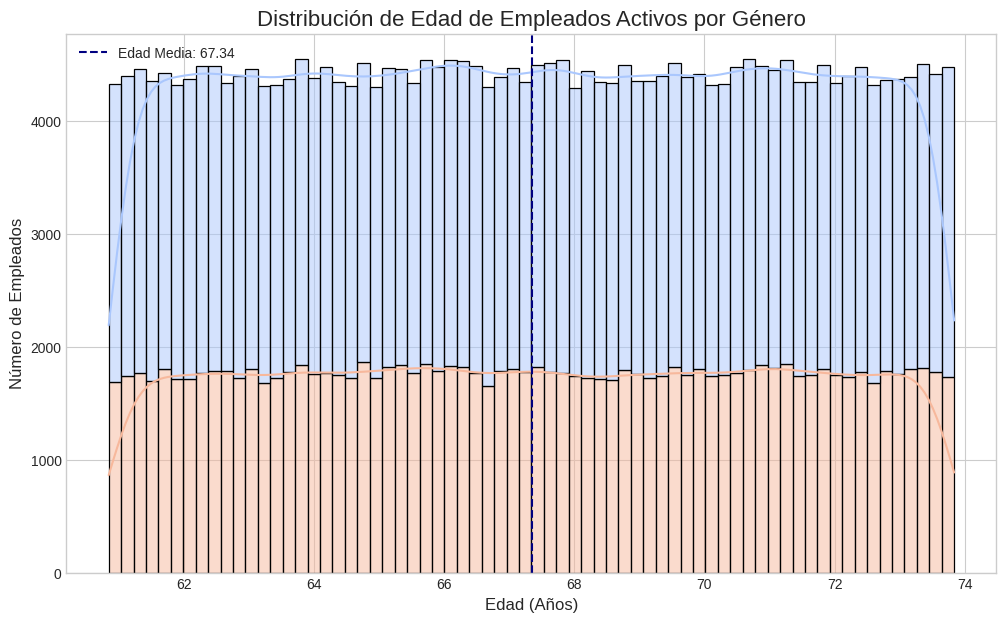

In [21]:
plt.style.use('seaborn-v0_8-whitegrid')
if not df.empty:
    plt.figure(figsize=(12, 7))
    sns.histplot(data=df, x='age', hue='gender', multiple='stack', kde=True, palette='coolwarm')
    plt.title('Distribución de Edad de Empleados Activos por Género', fontsize=16)
    plt.xlabel('Edad (Años)', fontsize=12)
    plt.ylabel('Número de Empleados', fontsize=12)
    plt.axvline(df['age'].mean(), color='navy', linestyle='--', label=f"Edad Media: {df['age'].mean():.2f}")
    plt.legend()
    plt.show()
else:
    print("El DataFrame está vacío. No se puede generar el gráfico de distribución de edad.")

### Análisis de la Distribución de Género

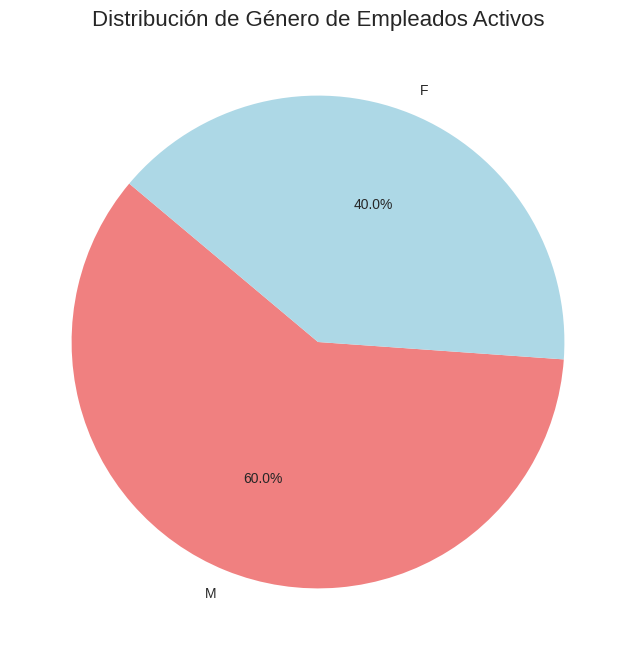

In [22]:
if not df.empty:
    gender_counts = df['gender'].value_counts()
    
    plt.figure(figsize=(8, 8))
    plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=140, colors=['lightcoral', 'lightblue'])
    plt.title('Distribución de Género de Empleados Activos', fontsize=16)
    plt.ylabel('') # Ocultar etiqueta del eje y
    plt.show()
else:
    print("El DataFrame está vacío. No se puede generar el gráfico de distribución de género.")

### Evolución de la Contratación por Género

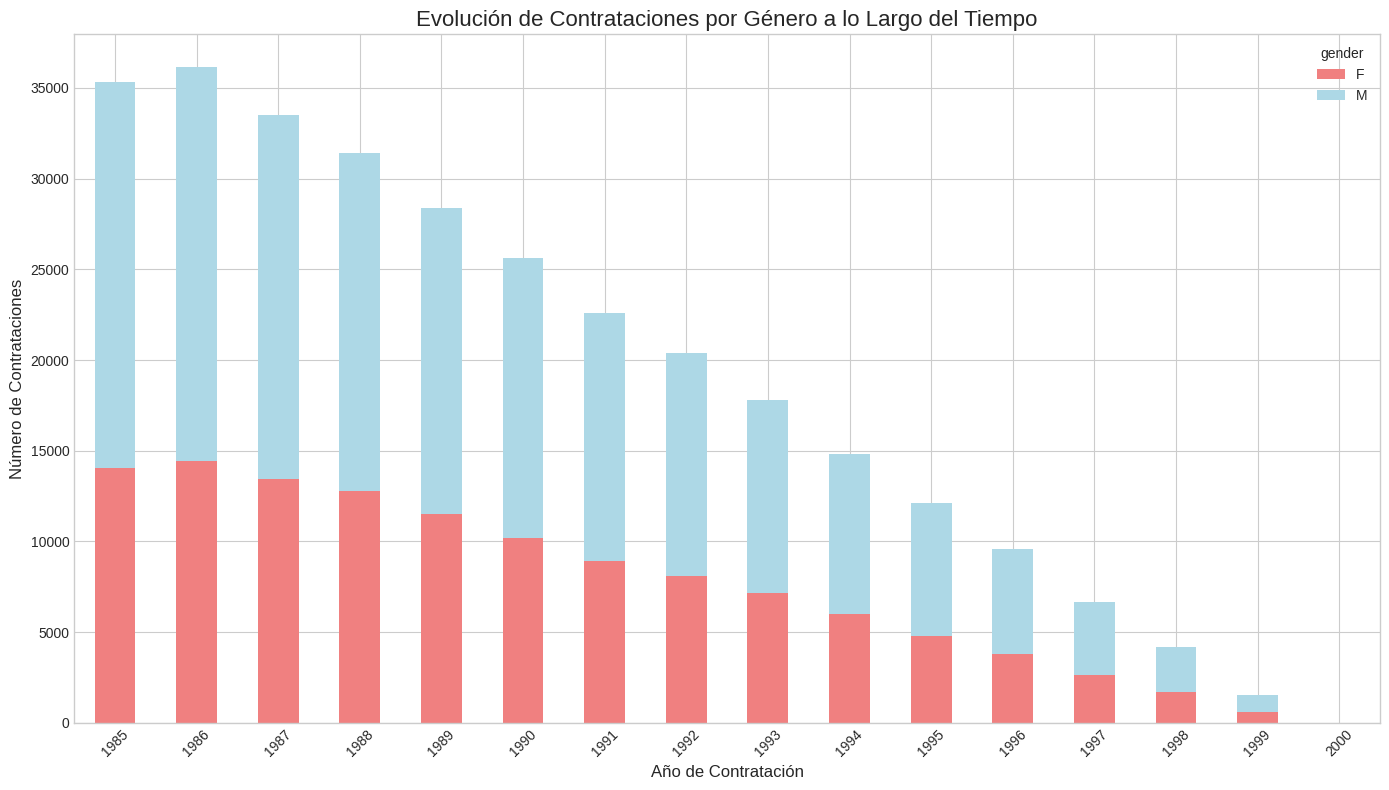

Conexión cerrada.


In [23]:
if not df.empty:
    df['hire_year'] = pd.to_datetime(df['hire_date']).dt.year
    hires_by_gender = df.groupby(['hire_year', 'gender']).size().unstack().fillna(0)
    
    hires_by_gender.plot(kind='bar', stacked=True, figsize=(14, 8), color=['lightcoral', 'lightblue'])
    plt.title('Evolución de Contrataciones por Género a lo Largo del Tiempo', fontsize=16)
    plt.xlabel('Año de Contratación', fontsize=12)
    plt.ylabel('Número de Contrataciones', fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("El DataFrame está vacío. No se puede generar el gráfico de evolución de contrataciones.")

# Cerrar la conexión
if 'conn' in locals() and conn is not None:
    conn.close()
    print("Conexión cerrada.")